In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import truncpareto

from pandemic_model.stats import fit_trunc_pareto, trunc_pareto_neg_log_likelihood

### Clean data and set bounds

In [2]:
lower_bound = 0.01
upper_bound = 1e4

In [3]:
df = pd.read_excel("../../data/raw/epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset data to 1900-present and to threshold-exceeding pandemics
df = df[(df["year_start"] >= 1900)].reset_index(drop=True)
df = df[(df["severity_smu"] >= lower_bound)]

## Change COVID-19 severity to ex ante estimate
with open("../../data/clean/inverted_covid_severity.yaml") as f:
		estimated_covid_severity = yaml.safe_load(f)

ex_ante_covid_severity = estimated_covid_severity['ex_ante_severity']
df.loc[df['disease'] == 'covid-19', 'severity_smu'] = ex_ante_covid_severity

## Subset to all novel viral pandemics amd to respiratory viruses
df_all = df[df['disease'].isin(['influenza', 'covid-19', 'ebola', 'hiv/aids'])
				].reset_index(drop=True)

In [4]:
b_init = 0.2
loc_init = 0.001
params = fit_trunc_pareto(df_all['severity_smu'], lower_bound, upper_bound, b_init=b_init, loc_init=loc_init, verbose=True)

Current parameters - b: 0.2000, loc: 0.0010, scale: 0.0090
Current negative log-likelihood: 31.0273
Current parameters - b: 0.2000, loc: 0.0010, scale: 0.0090
Current negative log-likelihood: 31.0273
Current parameters - b: 0.2000, loc: 0.0010, scale: 0.0090
Current negative log-likelihood: 31.0273
Current parameters - b: 0.0000, loc: 0.0000, scale: 0.0100
Current negative log-likelihood: 29.7934
Iteration parameters: [4.02387568e-11 2.03466243e-10]
Current parameters - b: 0.0000, loc: 0.0000, scale: 0.0100
Current negative log-likelihood: 29.7934
Current parameters - b: 0.0000, loc: 0.0000, scale: 0.0100
Current negative log-likelihood: 29.7934
Iteration parameters: [0.03163089 0.01      ]
Current parameters - b: 0.0032, loc: 0.0010, scale: 0.0090
Current negative log-likelihood: 29.7645
Current parameters - b: 0.0032, loc: 0.0010, scale: 0.0090
Current negative log-likelihood: 29.7645
Current parameters - b: 0.0032, loc: 0.0010, scale: 0.0090
Current negative log-likelihood: 29.7645


In [5]:
dist = truncpareto(params[0], (upper_bound - params[1]) / params[2], loc=params[1], scale=params[2])

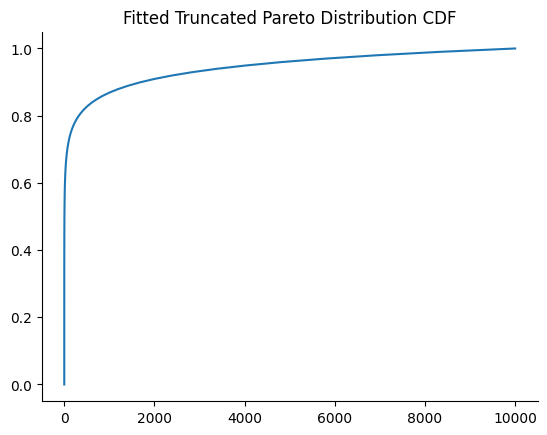

In [6]:
fig, ax = plt.subplots()
probs = np.linspace(0, 1, 100)
vals = dist.ppf(probs)
ax.plot(vals, probs)
ax.set_title("Fitted Truncated Pareto Distribution CDF")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [7]:
severity_df = pd.DataFrame({'severity': vals, 'rank': probs})
severity_df.to_csv("../../output/severity_distributions/truncpareto_sims.csv")

In [3]:
# Test whether the optimization script converges to true parameter values
# Define several test cases with different true parameters
test_cases = [
    # (true_b, true_loc, true_scale, true_c) - different parameter combinations
    (0.7, 0.2, 0.5, 1000),    # Original test case
    (1.5, 0.1, 0.3, 500),     # Steeper slope, smaller scale
    (0.3, 0.4, 0.8, 2000),    # Flatter slope, larger scale
    (2.0, 0.05, 0.2, 800),    # Very steep slope, small scale
    (0.5, 0.3, 0.6, 1500)     # Moderate slope, moderate scale
]

# Initial values to try for each test case
init_values = [
    (0.3, 0.1),  # (b_init, loc_init)
    (0.5, 0.3),
    (1.0, 0.15)
]

for test_idx, (true_b, true_loc, true_scale, true_c) in enumerate(test_cases, 1):
    print(f"\n{'='*80}")
    print(f"Test Case {test_idx}")
    print(f"True parameters: b={true_b}, loc={true_loc}, scale={true_scale}, c={true_c}")
    print('='*80)
    
    # Generate samples from true distribution
    test_dist = truncpareto(true_b, true_c, loc=true_loc, scale=true_scale)
    test_samples = test_dist.rvs(size=int(1e6), random_state=42+test_idx)
    
    # Set bounds based on true parameters
    lower_bound = true_loc + true_scale
    upper_bound = true_c * true_scale + true_loc
    
    best_params = None
    best_nll = float('inf')
    
    for b_init, loc_init in init_values:
        print(f"\nTrying initial values: b={b_init}, loc={loc_init}")
        try:
            params = fit_trunc_pareto(test_samples, lower_bound, upper_bound, 
                                    b_init=b_init, loc_init=loc_init, verbose=False)
        except RuntimeError as e:
            print(f"Optimization failed: {e}")
            continue
        
        # Calculate negative log-likelihood for these parameters
        nll = trunc_pareto_neg_log_likelihood(params[:2], test_samples, lower_bound, upper_bound)
        
        if nll < best_nll:
            best_nll = nll
            best_params = params
    
    # Report results for best parameters
    b_hat, loc_hat, scale_hat = best_params
    print("\nBest parameter estimates:")
    print(f"Shape (b)    - True: {true_b:.4f}, Estimated: {b_hat:.4f}, Rel. Error: {abs(b_hat-true_b)/true_b:.2%}")
    print(f"Location     - True: {true_loc:.4f}, Estimated: {loc_hat:.4f}, Rel. Error: {abs(loc_hat-true_loc)/true_loc:.2%}")
    print(f"Scale        - True: {true_scale:.4f}, Estimated: {scale_hat:.4f}, Rel. Error: {abs(scale_hat-true_scale)/true_scale:.2%}")


Test Case 1
True parameters: b=0.7, loc=0.2, scale=0.5, c=1000

Trying initial values: b=0.3, loc=0.1

Trying initial values: b=0.5, loc=0.3

Trying initial values: b=1.0, loc=0.15

Best parameter estimates:
Shape (b)    - True: 0.7000, Estimated: 0.6984, Rel. Error: 0.22%
Location     - True: 0.2000, Estimated: 0.2009, Rel. Error: 0.45%
Scale        - True: 0.5000, Estimated: 0.4991, Rel. Error: 0.18%

Test Case 2
True parameters: b=1.5, loc=0.1, scale=0.3, c=500

Trying initial values: b=0.3, loc=0.1
Optimization failed: Optimization error: MLE optimization failed:
Status: 4
Message: Inequality constraints incompatible
Try different initial values or bounds.

Trying initial values: b=0.5, loc=0.3

Trying initial values: b=1.0, loc=0.15

Best parameter estimates:
Shape (b)    - True: 1.5000, Estimated: 1.4941, Rel. Error: 0.39%
Location     - True: 0.1000, Estimated: 0.1016, Rel. Error: 1.61%
Scale        - True: 0.3000, Estimated: 0.2984, Rel. Error: 0.54%

Test Case 3
True paramete

c:\Users\squaade\Documents\Github\pandemic_model\python\.venv\Lib\site-packages\scipy\optimize\_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


Optimization failed: Optimization error: MLE optimization failed:
Status: 4
Message: Inequality constraints incompatible
Try different initial values or bounds.

Trying initial values: b=1.0, loc=0.15

Best parameter estimates:
Shape (b)    - True: 2.0000, Estimated: 1.3894, Rel. Error: 30.53%
Location     - True: 0.0500, Estimated: 0.1500, Rel. Error: 200.00%
Scale        - True: 0.2000, Estimated: 0.1000, Rel. Error: 50.00%

Test Case 5
True parameters: b=0.5, loc=0.3, scale=0.6, c=1500

Trying initial values: b=0.3, loc=0.1

Trying initial values: b=0.5, loc=0.3

Trying initial values: b=1.0, loc=0.15

Best parameter estimates:
Shape (b)    - True: 0.5000, Estimated: 0.4999, Rel. Error: 0.02%
Location     - True: 0.3000, Estimated: 0.2988, Rel. Error: 0.39%
Scale        - True: 0.6000, Estimated: 0.6012, Rel. Error: 0.20%
